## Test - Ivet


In [17]:
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

1. Load the sample data


In [18]:
file_features = Path("../data/processed/feature_based_clusters_2023.csv")

feature_df = pd.read_csv(file_features)

display(feature_df.head())
print("Shape:", feature_df.shape)
print("Columns:", feature_df.columns.tolist())

,ID,mean,median,std,cv,p90_p10_ratio,max_median_ratio,above_p90_fraction,trend_slope,acf1,...,catch22_DN_OutlierInclude_n_001_mdrmd,catch22_SP_Summaries_welch_rect_area_5_1,catch22_SB_BinaryStats_diff_longstretch0,catch22_SB_MotifThree_quantile_hh,catch22_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,catch22_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,catch22_SP_Summaries_welch_rect_centroid,catch22_FC_LocalSimple_mean3_stderr,Cluster,SparsityGroup
0,22,11.857921,11.432,3.973155,0.335063,2.367516,2.269419,0.10137,-0.009505,0.589803,...,0.267123,0.659493,4.0,2.115478,0.133333,0.844444,0.171806,0.789591,0,dense
1,42,14.054819,3.610,18.955428,1.348678,478.927928,22.506371,0.10137,-0.022695,0.907323,...,0.071233,0.902894,5.0,1.657275,0.822222,0.866667,0.036816,0.421801,0,dense
2,56,5.609575,5.739,5.210435,0.928847,94.763504,4.092699,0.10137,-0.016571,0.783508,...,0.221918,0.787504,6.0,1.783055,0.133333,0.822222,0.049087,0.621309,0,dense
3,58,9.320200,8.057,5.291708,0.567768,3.521269,4.936453,0.10137,0.016987,0.693289,...,0.268493,0.713175,6.0,2.047495,0.200000,0.222222,0.049087,0.705410,0,dense
4,64,2.438655,2.422,0.514874,0.211130,1.616140,1.816680,0.09863,-0.000220,0.110696,...,0.161644,0.332096,5.0,2.162988,0.133333,0.133333,1.362175,1.040229,0,dense


Shape: (17393, 59)
Columns: ['ID', 'mean', 'median', 'std', 'cv', 'p90_p10_ratio', 'max_median_ratio', 'above_p90_fraction', 'trend_slope', 'acf1', 'acf7', 'acf14', 'zero_fraction', 'nonzero_fraction', 'num_zero_runs', 'avg_zero_run_length', 'max_zero_run_length', 'nonzero_mean', 'nonzero_std', 'nonzero_median', 'rolling7_mean_std', 'rolling7_std_mean', 'weekday_0_norm', 'weekday_1_norm', 'weekday_2_norm', 'weekday_3_norm', 'weekday_4_norm', 'weekday_5_norm', 'weekday_6_norm', 'weekday_weekend_gap', 'burstiness', 'num_peaks', 'avg_peak_spacing', 'top10_first_half', 'top10_second_half', 'catch22_DN_HistogramMode_5', 'catch22_DN_HistogramMode_10', 'catch22_CO_f1ecac', 'catch22_CO_FirstMin_ac', 'catch22_CO_HistogramAMI_even_2_5', 'catch22_CO_trev_1_num', 'catch22_MD_hrv_classic_pnn40', 'catch22_SB_BinaryStats_mean_longstretch1', 'catch22_SB_TransitionMatrix_3ac_sumdiagcov', 'catch22_PD_PeriodicityWang_th0_01', 'catch22_CO_Embed2_Dist_tau_d_expfit_meandiff', 'catch22_IN_AutoMutualInfoStats

2. keeo just the num


In [19]:
drop_cols = ["ID", "Cluster", "SparsityGroup", "RefinedCluster", "RefinedClusterLocal"]
drop_cols = [c for c in drop_cols if c in feature_df.columns]

numeric_cols = [
    c
    for c in feature_df.columns
    if c not in drop_cols and pd.api.types.is_numeric_dtype(feature_df[c])
]

print("Number of numeric feature columns:", len(numeric_cols))
print(numeric_cols[:20])

Number of numeric feature columns: 56
['mean', 'median', 'std', 'cv', 'p90_p10_ratio', 'max_median_ratio', 'above_p90_fraction', 'trend_slope', 'acf1', 'acf7', 'acf14', 'zero_fraction', 'nonzero_fraction', 'num_zero_runs', 'avg_zero_run_length', 'max_zero_run_length', 'nonzero_mean', 'nonzero_std', 'nonzero_median', 'rolling7_mean_std']


3. Haevy-tail stabilization

In [20]:
def winsorize_series(s, lower_q=0.01, upper_q=0.99):
    lower = s.quantile(lower_q)
    upper = s.quantile(upper_q)
    return s.clip(lower=lower, upper=upper)


def is_heavy_tailed(s, ratio_threshold=10, skew_threshold=2):
    s = s.dropna()
    if len(s) == 0:
        return False
    q50 = s.quantile(0.50)
    q99 = s.quantile(0.99)
    ratio = (q99 + 1e-12) / (abs(q50) + 1e-12)
    skew = s.skew() if len(s) > 2 else 0
    return (ratio >= ratio_threshold) or (abs(skew) >= skew_threshold)

In [21]:
feature_df_clean = feature_df.copy()

heavy_tail_cols = []
for col in numeric_cols:
    if is_heavy_tailed(feature_df_clean[col]):
        heavy_tail_cols.append(col)

print("Heavy-tailed columns detected:", len(heavy_tail_cols))
print(heavy_tail_cols)

Heavy-tailed columns detected: 40
['mean', 'median', 'std', 'cv', 'p90_p10_ratio', 'max_median_ratio', 'above_p90_fraction', 'trend_slope', 'zero_fraction', 'nonzero_fraction', 'num_zero_runs', 'avg_zero_run_length', 'max_zero_run_length', 'nonzero_mean', 'nonzero_std', 'nonzero_median', 'rolling7_mean_std', 'rolling7_std_mean', 'weekday_0_norm', 'weekday_1_norm', 'weekday_2_norm', 'weekday_3_norm', 'weekday_4_norm', 'weekday_5_norm', 'weekday_weekend_gap', 'num_peaks', 'avg_peak_spacing', 'catch22_CO_f1ecac', 'catch22_CO_FirstMin_ac', 'catch22_CO_trev_1_num', 'catch22_MD_hrv_classic_pnn40', 'catch22_SB_BinaryStats_mean_longstretch1', 'catch22_SB_TransitionMatrix_3ac_sumdiagcov', 'catch22_PD_PeriodicityWang_th0_01', 'catch22_CO_Embed2_Dist_tau_d_expfit_meandiff', 'catch22_IN_AutoMutualInfoStats_40_gaussian_fmmi', 'catch22_FC_LocalSimple_mean1_tauresrat', 'catch22_DN_OutlierInclude_p_001_mdrmd', 'catch22_DN_OutlierInclude_n_001_mdrmd', 'catch22_SB_MotifThree_quantile_hh']


In [ ]:
for col in numeric_cols:
    feature_df_clean[col] = winsorize_series(feature_df_clean[col], 0.01, 0.99)

for col in heavy_tail_cols:
    if (feature_df_clean[col] >= 0).all():
        feature_df_clean[col] = np.log1p(feature_df_clean[col])

display(feature_df_clean.head())

,ID,mean,median,std,cv,p90_p10_ratio,max_median_ratio,above_p90_fraction,trend_slope,acf1,...,catch22_DN_OutlierInclude_n_001_mdrmd,catch22_SP_Summaries_welch_rect_area_5_1,catch22_SB_BinaryStats_diff_longstretch0,catch22_SB_MotifThree_quantile_hh,catch22_SC_FluctAnal_2_rsrangefit_50_1_logi_prop_r1,catch22_SC_FluctAnal_2_dfa_50_1_2_logi_prop_r1,catch22_SP_Summaries_welch_rect_centroid,catch22_FC_LocalSimple_mean3_stderr,Cluster,SparsityGroup
0,22,2.553960,2.520274,1.604054,0.288979,1.214175,1.184612,0.096555,-0.009505,0.589803,...,0.267123,0.659493,4.0,1.136383,0.133333,0.844444,0.171806,0.789591,0,dense
1,42,2.711698,1.528228,2.993501,0.853853,5.183883,3.157271,0.096555,-0.022695,0.907323,...,0.071233,0.902894,5.0,0.977301,0.822222,0.866667,0.036816,0.421801,0,dense
2,56,1.888519,1.907912,1.826231,0.656922,4.561882,1.627808,0.096555,-0.016571,0.783508,...,0.221918,0.787504,6.0,1.023549,0.133333,0.822222,0.049087,0.621309,0,dense
3,58,2.334103,2.203538,1.839233,0.449653,1.508793,1.781112,0.096555,0.016987,0.693289,...,0.268493,0.713175,6.0,1.114320,0.200000,0.222222,0.049087,0.705410,0,dense
4,64,1.235080,1.230225,0.415333,0.191554,0.961700,1.035559,0.094064,-0.000220,0.110696,...,0.161644,0.332096,5.0,1.151517,0.133333,0.133333,1.362175,1.040229,0,dense


4. bucket for zero-heavy

In [23]:
assert "zero_fraction" in feature_df_clean.columns, "zero_fraction column is required"


def sparsity_bucket(z):
    if z < 0.05:
        return "dense"
    elif z < 0.25:
        return "moderate_zero"
    else:
        return "high_zero"


feature_df_clean["SparsityBucket"] = feature_df_clean["zero_fraction"].apply(
    sparsity_bucket
)

display(feature_df_clean["SparsityBucket"].value_counts())

SparsityBucket
dense            16648
high_zero          450
moderate_zero      295
Name: count, dtype: int64

5.helper functions

In [ ]:
def get_feature_matrix(df):
    exclude = {
        "ID",
        "Cluster",
        "SparsityGroup",
        "RefinedCluster",
        "RefinedClusterLocal",
        "SparsityBucket",
    }
    cols = [
        c
        for c in df.columns
        if c not in exclude and pd.api.types.is_numeric_dtype(df[c])
    ]
    X = df[cols].copy()
    return X, cols


def evaluate_kmeans(X_scaled, k, random_state=42):
    model = KMeans(n_clusters=k, random_state=random_state, n_init=20)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(
        X_scaled,
        labels,
        sample_size=min(5000, len(X_scaled)),
        random_state=random_state,
    )
    return model, labels, sil


def evaluate_gmm(X_scaled, k, random_state=42):
    model = GaussianMixture(
        n_components=k,
        covariance_type="diag",
        random_state=random_state,
        n_init=3,
        reg_covar=1e-6,
    )
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(
        X_scaled,
        labels,
        sample_size=min(5000, len(X_scaled)),
        random_state=random_state,
    )
    return model, labels, sil


def cluster_size_table(labels):
    s = pd.Series(labels).value_counts().sort_index()
    out = pd.DataFrame(
        {"cluster": s.index, "count": s.values, "pct": 100 * s.values / s.values.sum()}
    )
    return out

6. run model

In [ ]:
k_values = [3, 4, 5, 6, 8]
results = []
best_models = {}

for bucket_name, bucket_df in feature_df_clean.groupby("SparsityBucket"):
    print(f"\n=== Bucket: {bucket_name} | n={len(bucket_df)} ===")
    
    X_bucket, feat_cols = get_feature_matrix(bucket_df)
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X_bucket)
    
    bucket_results = []
    
    for k in k_values:
        # KMeans
        km_model, km_labels, km_sil = evaluate_kmeans(X_scaled, k)
        bucket_results.append({
            "bucket": bucket_name,
            "method": "kmeans",
            "k": k,
            "silhouette": km_sil
        })
        
        # GMM
        gmm_model, gmm_labels, gmm_sil = evaluate_gmm(X_scaled, k)
        bucket_results.append({
            "bucket": bucket_name,
            "method": "gmm",
            "k": k,
            "silhouette": gmm_sil
        })
    
    bucket_results_df = pd.DataFrame(bucket_results).sort_values("silhouette", ascending=False)
    display(bucket_results_df)
    
    best_row = bucket_results_df.iloc[0]
    best_method = best_row["method"]
    best_k = int(best_row["k"])
    
    print(f"Best for {bucket_name}: {best_method}, k={best_k}, silhouette={best_row['silhouette']:.4f}")
    
    if best_method == "kmeans":
        best_model, best_labels, best_sil = evaluate_kmeans(X_scaled, best_k)
    else:
        best_model, best_labels, best_sil = evaluate_gmm(X_scaled, best_k)
    
    best_models[bucket_name] = {
        "model": best_model,
        "labels": best_labels,
        "scaler": scaler,
        "feature_cols": feat_cols,
        "silhouette": best_sil,
        "method": best_method,
        "k": best_k,
        "index": bucket_df.index
    }
    
    results.append(bucket_results_df)

results_df = pd.concat(results, ignore_index=True)
display(results_df.sort_values(["bucket", "silhouette"], ascending=[True, False]))


=== Bucket: dense | n=16648 ===


,bucket,method,k,silhouette
0,dense,kmeans,3,0.283811
2,dense,kmeans,4,0.184161
1,dense,gmm,3,0.166887
4,dense,kmeans,5,0.163491
6,dense,kmeans,6,0.129055
8,dense,kmeans,8,0.126706
3,dense,gmm,4,0.033149
5,dense,gmm,5,0.023833
7,dense,gmm,6,0.009373
9,dense,gmm,8,-0.013543


Best for dense: kmeans, k=3, silhouette=0.2838

=== Bucket: high_zero | n=450 ===


,bucket,method,k,silhouette
6,high_zero,kmeans,6,0.187391
4,high_zero,kmeans,5,0.181812
2,high_zero,kmeans,4,0.168269
8,high_zero,kmeans,8,0.155689
0,high_zero,kmeans,3,0.151555
1,high_zero,gmm,3,0.093689
3,high_zero,gmm,4,0.081735
5,high_zero,gmm,5,0.067901
9,high_zero,gmm,8,0.063122
7,high_zero,gmm,6,0.044396


Best for high_zero: kmeans, k=6, silhouette=0.1874

=== Bucket: moderate_zero | n=295 ===


,bucket,method,k,silhouette
0,moderate_zero,kmeans,3,0.215370
2,moderate_zero,kmeans,4,0.210457
4,moderate_zero,kmeans,5,0.202293
6,moderate_zero,kmeans,6,0.200350
8,moderate_zero,kmeans,8,0.120611
5,moderate_zero,gmm,5,0.085168
9,moderate_zero,gmm,8,0.063778
1,moderate_zero,gmm,3,0.063122
7,moderate_zero,gmm,6,0.060030
3,moderate_zero,gmm,4,0.037071


Best for moderate_zero: kmeans, k=3, silhouette=0.2154


,bucket,method,k,silhouette
0,dense,kmeans,3,0.283811
1,dense,kmeans,4,0.184161
2,dense,gmm,3,0.166887
3,dense,kmeans,5,0.163491
4,dense,kmeans,6,0.129055
5,dense,kmeans,8,0.126706
6,dense,gmm,4,0.033149
7,dense,gmm,5,0.023833
8,dense,gmm,6,0.009373
9,dense,gmm,8,-0.013543


7. labels back

In [26]:
feature_df_clean["RefinedClusterLocal"] = -999
feature_df_clean["RefinedCluster"] = None

for bucket_name, info in best_models.items():
    idx = info["index"]
    labels = info["labels"]
    
    feature_df_clean.loc[idx, "RefinedClusterLocal"] = labels
    feature_df_clean.loc[idx, "RefinedCluster"] = [
        f"{bucket_name}_{int(l)}" for l in labels
    ]

display(feature_df_clean[["ID", "SparsityBucket", "RefinedClusterLocal", "RefinedCluster"]].head())

,ID,SparsityBucket,RefinedClusterLocal,RefinedCluster
0,22,dense,2,dense_2
1,42,dense,1,dense_1
2,56,dense,1,dense_1
3,58,dense,2,dense_2
4,64,dense,2,dense_2


8. check size

In [27]:
cluster_sizes = feature_df_clean["RefinedCluster"].value_counts().reset_index()
cluster_sizes.columns = ["Cluster", "Count"]
cluster_sizes["Pct"] = 100 * cluster_sizes["Count"] / cluster_sizes["Count"].sum()

display(cluster_sizes.sort_values("Count", ascending=False))

,Cluster,Count,Pct
0,dense_2,12381,71.183810
1,dense_0,2295,13.194963
2,dense_1,1972,11.337895
3,moderate_zero_1,221,1.270626
4,high_zero_5,165,0.948658
5,high_zero_1,80,0.459955
6,high_zero_2,57,0.327718
7,high_zero_4,53,0.304720
8,moderate_zero_2,52,0.298971
9,high_zero_3,48,0.275973


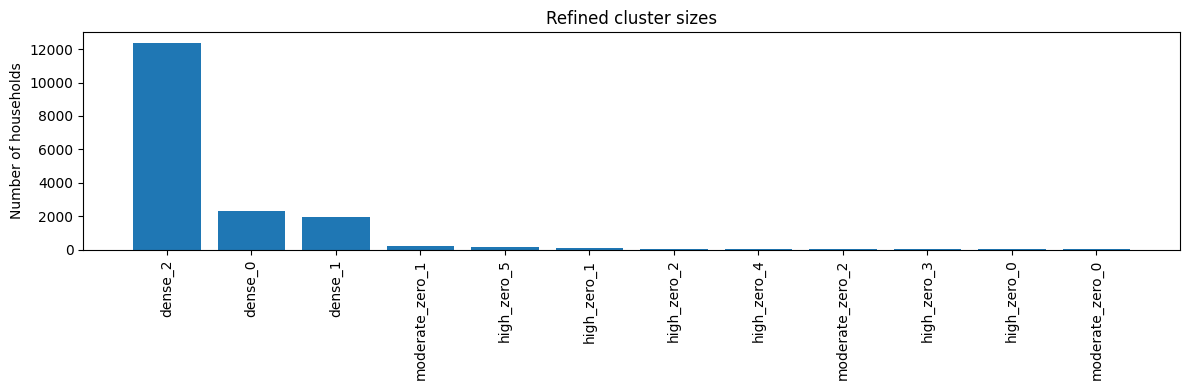

In [28]:
plt.figure(figsize=(12, 4))
plt.bar(cluster_sizes["Cluster"], cluster_sizes["Count"])
plt.xticks(rotation=90)
plt.title("Refined cluster sizes")
plt.ylabel("Number of households")
plt.tight_layout()
plt.show()

9. summurise

In [ ]:
summary_cols = [
    c
    for c in [
        "mean",
        "std",
        "cv",
        "zero_fraction",
        "avg_zero_run_length",
        "acf7",
        "trend_slope",
        "weekday_weekend_gap",
        "burstiness",
        "num_peaks",
    ]
    if c in feature_df_clean.columns
]

cluster_summary = feature_df_clean.groupby("RefinedCluster")[summary_cols].mean()
display(cluster_summary.sort_index())

,mean,std,cv,zero_fraction,avg_zero_run_length,acf7,trend_slope,weekday_weekend_gap,burstiness,num_peaks
RefinedCluster,,,,,,,,,,
dense_0,1.920013,1.696693,0.584300,0.000610,0.048846,0.516436,0.007567,-0.020303,-0.141477,4.661752
dense_1,2.876138,2.518797,0.531308,0.000830,0.062726,0.749601,-0.029424,-0.019685,-0.186414,4.693944
dense_2,2.004763,1.207699,0.312905,0.000330,0.027700,0.270694,-0.000342,-0.069682,-0.468649,4.757715
high_zero_0,0.417641,0.649291,1.227407,0.452167,2.824182,0.105202,0.000379,-0.389474,0.410084,3.982000
high_zero_1,2.574863,2.609264,0.732581,0.340966,3.340285,0.826700,-0.035762,0.016081,0.032031,4.198768
high_zero_2,0.438621,0.588726,1.131960,0.420757,2.249538,0.157921,-0.000758,0.438777,0.337376,4.200089
high_zero_3,0.695350,1.039366,1.158592,0.422372,2.827181,0.294772,0.004961,-0.023004,0.362358,4.039784
high_zero_4,0.506486,0.825221,1.201925,0.445525,2.626590,0.125303,0.000491,0.063673,0.389171,3.986995
high_zero_5,1.143772,1.334419,0.870895,0.389525,3.239883,0.686485,0.002167,-0.029855,0.148581,4.118860


10. vis pca

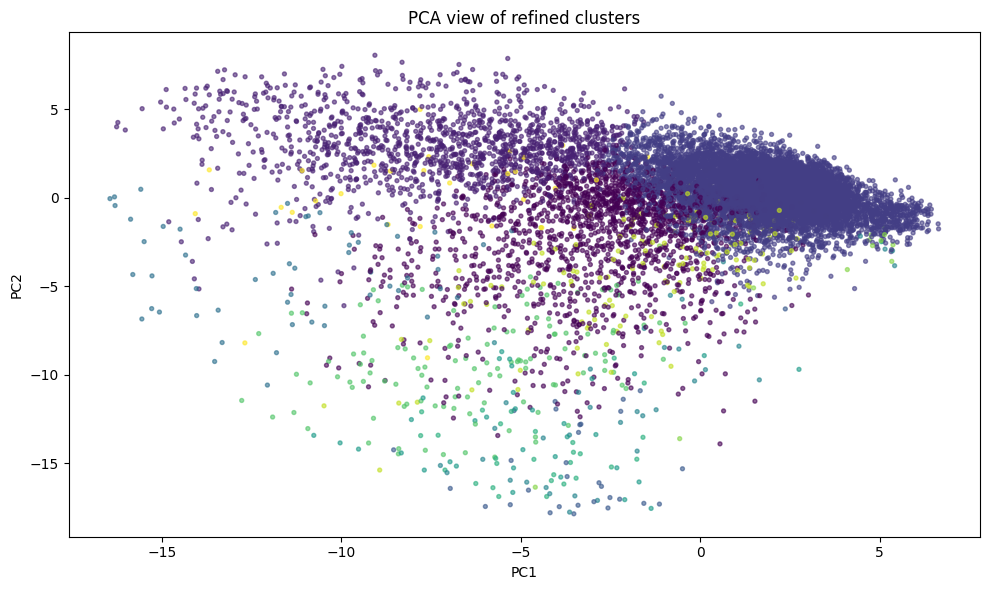

In [ ]:
X_all, feat_cols = get_feature_matrix(feature_df_clean)
scaler_all = RobustScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_all_scaled)

plot_df = pd.DataFrame(
    {
        "PC1": X_2d[:, 0],
        "PC2": X_2d[:, 1],
        "Cluster": feature_df_clean["RefinedCluster"].values,
    }
)

sample_plot_df = plot_df.sample(min(12000, len(plot_df)), random_state=42)

cluster_to_int = {
    c: i for i, c in enumerate(sorted(sample_plot_df["Cluster"].unique()))
}
colors = sample_plot_df["Cluster"].map(cluster_to_int)

plt.figure(figsize=(10, 6))
plt.scatter(sample_plot_df["PC1"], sample_plot_df["PC2"], c=colors, s=8, alpha=0.6)
plt.title("PCA view of refined clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

11. save results

In [31]:
output_file = Path("../data/processed/feature_based_clusters_2023_refined.csv")
feature_df_clean.to_csv(output_file, index=False)

print("Saved refined clustering result to:")
print(output_file)

Saved refined clustering result to:
../data/processed/feature_based_clusters_2023_refined.csv


In [ ]:
for i in range(feature_df_clean["RefinedClusterLocal"].nunique()):
    count = (feature_df_clean["RefinedClusterLocal"] == i).sum()
    print(f"Cluster {i}: {count} households") 

Cluster 0: 2364 households
Cluster 1: 2273 households
Cluster 2: 12490 households
Cluster 3: 48 households
Cluster 4: 53 households
Cluster 5: 165 households
